# Projekt 3 — Ewaluacja: uwierzytelnianie twarzą *in-the-wild*

Utrudnienia: **#3 niska rozdzielczość (CCTV)** i **#1 wiele twarzy**. Backbone ArcFace
`iresnet50` zamrożony; odporność = triki test-time. Cel: FRR ≤ +5 pp, TIR ≥ −5 pp na
trudnych vs czystych.

Notebook korzysta z funkcji `evaluate.py` (embeddingi z cache `artifacts/results/emb_*.pkl`),
więc wykresy generują się szybko. Najpierw uruchom: `build_split.py → enroll.py → build_test_sets.py`.

In [1]:
import json, pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import evaluate as E
from config import DATA_DIR, RESULTS_DIR, COS_DIST_THRESHOLD
from pipeline.matcher import load_db

manifest = json.loads((DATA_DIR / 'manifest.json').read_text())
db = load_db()
gallery = E.build_gallery(db)
DIFFS = ['clean', 'lowres', 'multiface']
COLORS = {'clean':'#2a9d8f', 'lowres':'#e76f51', 'multiface':'#264653'}
print(f'manifest: {len(manifest)} próbek | baza: {len(db)} użytkowników')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

manifest: 7001 próbek | baza: 100 użytkowników


## 1. Przegląd zbiorów testowych

utrudnienie    razem  genuine impostor
clean           1103      983      120
lowres          2949     2949        0
multiface       2949     2949        0
SUMA            7001

Trudnych łącznie: 5898 (cel ≥5000), czystych: 1103 (cel ≥1000)


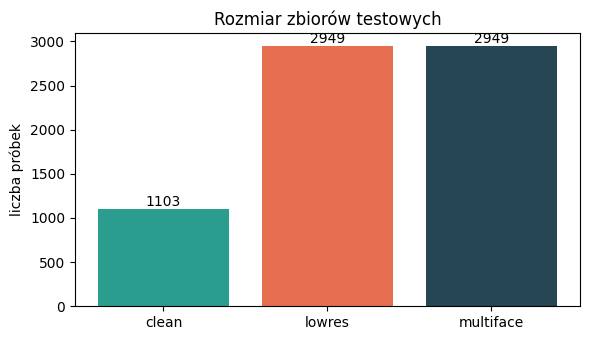

In [2]:
from collections import Counter
cnt = Counter(m['difficulty'] for m in manifest)
gen = Counter(m['difficulty'] for m in manifest if 'identity' in m)
imp = Counter(m['difficulty'] for m in manifest if 'impostor' in m)
print(f"{'utrudnienie':<12}{'razem':>8}{'genuine':>9}{'impostor':>9}")
for d in DIFFS:
    print(f'{d:<12}{cnt.get(d,0):>8}{gen.get(d,0):>9}{imp.get(d,0):>9}')
print(f"{'SUMA':<12}{sum(cnt.values()):>8}")
print(f"\nTrudnych łącznie: {cnt.get('lowres',0)+cnt.get('multiface',0)} (cel ≥5000), "
      f"czystych: {cnt.get('clean',0)} (cel ≥1000)")

fig, ax = plt.subplots(figsize=(6,3.5))
ax.bar(DIFFS, [cnt.get(d,0) for d in DIFFS], color=[COLORS[d] for d in DIFFS])
ax.set_ylabel('liczba próbek'); ax.set_title('Rozmiar zbiorów testowych')
for i,d in enumerate(DIFFS): ax.text(i, cnt.get(d,0), str(cnt.get(d,0)), ha='center', va='bottom')
plt.tight_layout(); plt.show()

### Przykładowe próbki: czysta vs trudne (ta sama osoba)

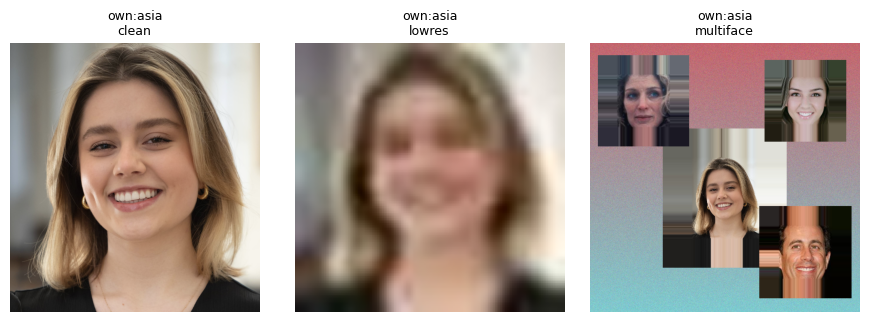

In [3]:
import cv2
def show_bgr(ax, path, title):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')

# wybierz osobę, która ma próbki we wszystkich utrudnieniach
by_id = {}
for m in manifest:
    if 'identity' in m:
        by_id.setdefault(m['identity'], {}).setdefault(m['difficulty'], m['path'])
person = next(i for i,d in by_id.items() if all(k in d for k in DIFFS))
fig, axs = plt.subplots(1, 3, figsize=(9,3.2))
for ax, d in zip(axs, DIFFS): show_bgr(ax, by_id[person][d], f'{person}\n{d}')
plt.tight_layout(); plt.show()

## 2. Embeddingi (cache)
Liczone raz na konfigurację. `full` = wszystkie triki; `baseline` = czysty ArcFace bez trików.

In [4]:
records = {'full': E.compute_embeddings(manifest, 'full'),
           'baseline': E.compute_embeddings(manifest, 'baseline')}
def split_diff(recs):
    out = {d: [] for d in DIFFS}
    for r in recs: out.setdefault(r['difficulty'], []).append(r)
    return out
rec_by = {c: split_diff(records[c]) for c in records}
print('gotowe:', {c: {d: len(rec_by[c][d]) for d in DIFFS} for c in records})

  [full] 250/7001
  [full] 500/7001
  [full] 750/7001
  [full] 1000/7001
  [full] 1250/7001


  [full] 1500/7001
  [full] 1750/7001
  [full] 2000/7001
  [full] 2250/7001


  [full] 2500/7001
  [full] 2750/7001
  [full] 3000/7001
  [full] 3250/7001
  [full] 3500/7001


  [full] 3750/7001
  [full] 4000/7001
  [full] 4250/7001
  [full] 4500/7001


  [full] 4750/7001
  [full] 5000/7001
  [full] 5250/7001
  [full] 5500/7001
  [full] 5750/7001


...

  [baseline] 1750/7001
  [baseline] 2000/7001
  [baseline] 2250/7001
  [baseline] 2500/7001
  [baseline] 2750/7001


  [baseline] 3000/7001
  [baseline] 3250/7001
  [baseline] 3500/7001
  [baseline] 3750/7001
  [baseline] 4000/7001
  [baseline] 4250/7001


  [baseline] 4500/7001
  [baseline] 4750/7001
  [baseline] 5000/7001
  [baseline] 5250/7001
  [baseline] 5500/7001


  [baseline] 5750/7001
  [baseline] 6000/7001
  [baseline] 6250/7001
  [baseline] 6500/7001
  [baseline] 6750/7001


  [baseline] 7000/7001
gotowe: {'full': {'clean': 1103, 'lowres': 2949, 'multiface': 2949}, 'baseline': {'clean': 1103, 'lowres': 2949, 'multiface': 2949}}


## 3. Weryfikacja — próg, ROC, FAR/FRR
Próg dobrany w punkcie EER na zbiorze **clean** (pełny pipeline), potem stosowany do trudnych.

In [5]:
# próg operacyjny: @FAR=1% na clean (stabilniejszy niż EER przy idealnej separacji)
v_clean = E.verification(rec_by['full']['clean'], gallery, COS_DIST_THRESHOLD, use_adaptive=True)
eer_c, _, auc_c = E.eer_threshold(v_clean['genuine'], v_clean['impostor'])
THR = E.threshold_at_far(v_clean['impostor'], target_far=0.01)
print(f'Próg @FAR=1% (clean) = {THR:.4f}   EER_clean = {100*eer_c:.2f}%   AUC = {auc_c:.4f}')

Próg @FAR=1% (clean) = 0.7735   EER_clean = 0.57%   AUC = 0.9987


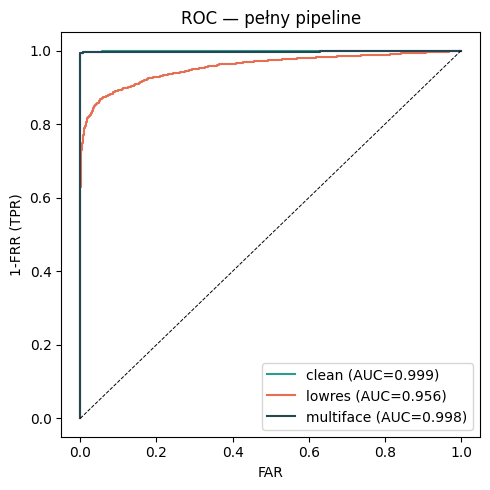

In [6]:
# ROC per utrudnienie (pełny pipeline)
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(5,5))
for d in DIFFS:
    v = E.verification(rec_by['full'][d], gallery, THR, use_adaptive=True)
    if len(v['genuine'])==0: continue
    s = np.concatenate([v['genuine'], v['impostor']])
    y = np.concatenate([np.ones(len(v['genuine'])), np.zeros(len(v['impostor']))])
    fpr,tpr,_ = roc_curve(y, -s)
    ax.plot(fpr, tpr, color=COLORS[d], label=f'{d} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=.7); ax.set_xlabel('FAR'); ax.set_ylabel('1-FRR (TPR)')
ax.set_title('ROC — pełny pipeline'); ax.legend(); plt.tight_layout(); plt.show()

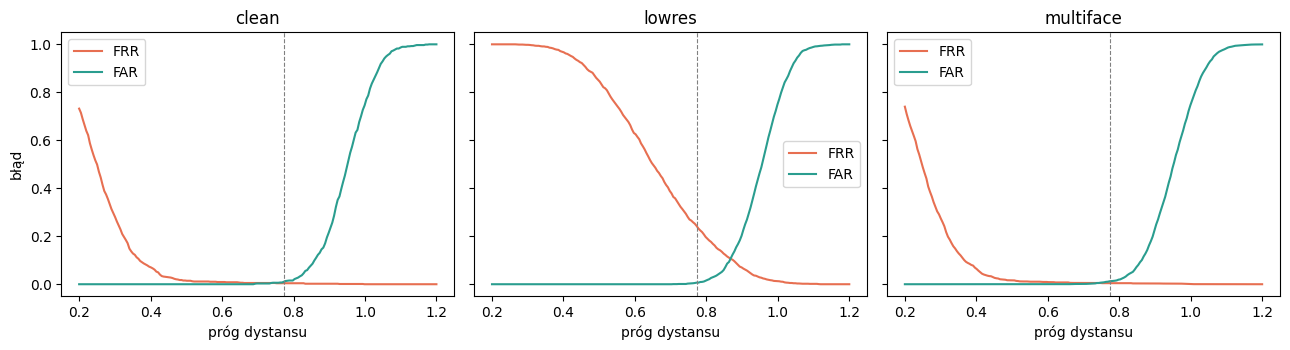

In [7]:
# FAR/FRR vs próg
ths = np.linspace(0.2, 1.2, 200)
fig, axs = plt.subplots(1, 3, figsize=(13,3.6), sharey=True)
for ax, d in zip(axs, DIFFS):
    v = E.verification(rec_by['full'][d], gallery, THR, use_adaptive=True)
    g, im = v['genuine'], v['impostor']
    if len(g)==0: continue
    frr = [np.mean(g> t) for t in ths]; far = [np.mean(im<=t) for t in ths]
    ax.plot(ths, frr, label='FRR', color='#e76f51'); ax.plot(ths, far, label='FAR', color='#2a9d8f')
    ax.axvline(THR, ls='--', c='gray', lw=.8); ax.set_title(d); ax.set_xlabel('próg dystansu')
    ax.legend()
axs[0].set_ylabel('błąd'); plt.tight_layout(); plt.show()

## 4. Identyfikacja — TIR (Top-1 / Top-5)

clean        Top-1=99.59%  Top-5=99.79%  odrzuc.impostorów=34.45%
lowres       Top-1=77.37%  Top-5=87.48%  odrzuc.impostorów=0.00%
multiface    Top-1=99.56%  Top-5=99.66%  odrzuc.impostorów=0.00%


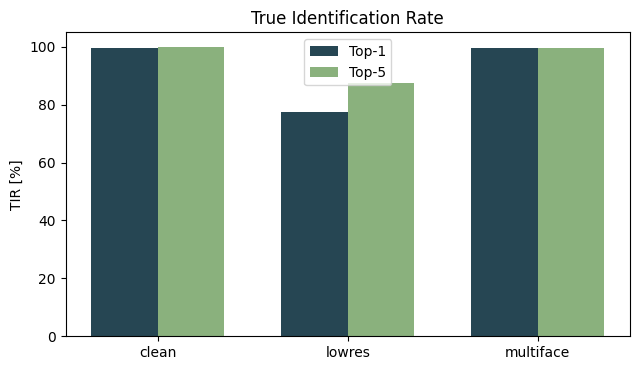

In [8]:
tir = {}
for d in DIFFS:
    idi = E.identification(rec_by['full'][d], gallery, THR, use_adaptive=True)
    tir[d] = idi
x = np.arange(len(DIFFS)); w=0.35
fig, ax = plt.subplots(figsize=(6.5,3.8))
ax.bar(x-w/2, [100*tir[d]['TIR_top1'] for d in DIFFS], w, label='Top-1', color='#264653')
ax.bar(x+w/2, [100*tir[d]['TIR_top5'] for d in DIFFS], w, label='Top-5', color='#8ab17d')
ax.set_xticks(x); ax.set_xticklabels(DIFFS); ax.set_ylabel('TIR [%]'); ax.set_ylim(0,105)
ax.set_title('True Identification Rate'); ax.legend()
for d in DIFFS:
    print(f"{d:<12} Top-1={100*tir[d]['TIR_top1']:.2f}%  Top-5={100*tir[d]['TIR_top5']:.2f}%  "
          f"odrzuc.impostorów={100*tir[d]['reject_rate_impostor']:.2f}%")
plt.tight_layout(); plt.show()

## 5. Cel: degradacja ≤ 5 pp (pełny pipeline)
ΔFRR = FRR(trudne) − FRR(clean); ΔTIR = TIR(trudne) − TIR(clean).

In [9]:
base = E.verification(rec_by['full']['clean'], gallery, THR, use_adaptive=True)
frr_clean = base['FRR']; tir_clean = tir['clean']['TIR_top1']
print(f"{'utrudnienie':<12}{'FRR':>8}{'ΔFRR':>9}{'TIR@1':>9}{'ΔTIR':>9}   cel")
for d in DIFFS:
    v = E.verification(rec_by['full'][d], gallery, THR, use_adaptive=True)
    dfrr = 100*(v['FRR']-frr_clean); dtir = 100*(tir[d]['TIR_top1']-tir_clean)
    ok = '✓' if (d=='clean' or (dfrr<=5 and dtir>=-5)) else '✗ (>5pp)'
    print(f'{d:<12}{100*v["FRR"]:>7.2f}%{dfrr:>+8.2f}{100*tir[d]["TIR_top1"]:>8.2f}%{dtir:>+8.2f}   {ok}')

utrudnienie      FRR     ΔFRR    TIR@1     ΔTIR   cel
clean          0.41%   +0.00   99.59%   +0.00   ✓
lowres        17.24%  +16.83   77.37%  -22.21   ✗ (>5pp)
multiface      0.44%   +0.03   99.56%   -0.03   ✓


## 6. Ablacja: pełny pipeline vs baseline (bez trików)
Pokazuje, ile triki realnie nadrabiają na trudnych próbkach (przy tym samym progu).

utrudn.      FRR base  FRR full  TIR base  TIR full
clean           0.51%     0.41%    99.59%    99.59%
lowres         45.30%    17.24%    55.68%    77.37%
multiface      85.42%     0.44%    14.72%    99.56%


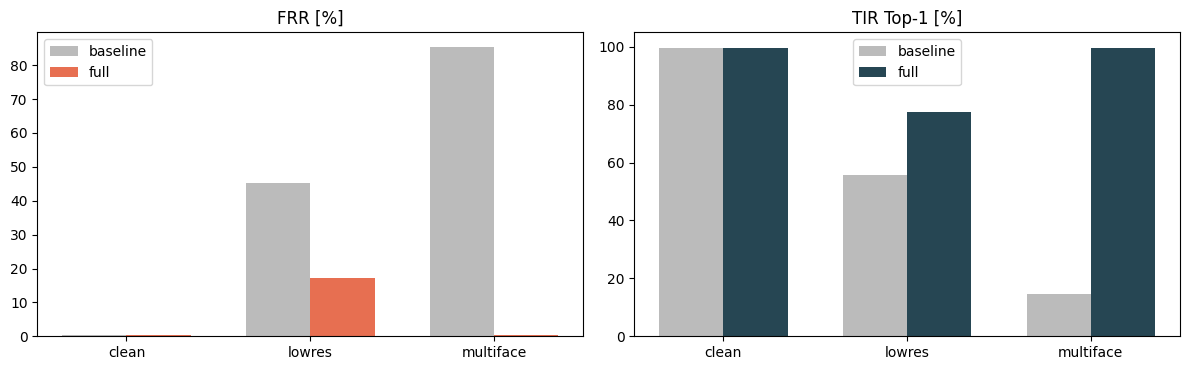

In [10]:
def metrics_for(cfg, d, adaptive):
    v = E.verification(rec_by[cfg][d], gallery, THR, use_adaptive=adaptive)
    idi = E.identification(rec_by[cfg][d], gallery, THR, use_adaptive=adaptive)
    return v['FRR'], idi['TIR_top1']
rows = []
for d in DIFFS:
    fb, tb = metrics_for('baseline', d, False)
    ff, tf = metrics_for('full', d, True)
    rows.append((d, fb, ff, tb, tf))
print(f"{'utrudn.':<11}{'FRR base':>10}{'FRR full':>10}{'TIR base':>10}{'TIR full':>10}")
for d,fb,ff,tb,tf in rows:
    print(f'{d:<11}{100*fb:>9.2f}%{100*ff:>9.2f}%{100*tb:>9.2f}%{100*tf:>9.2f}%')

x = np.arange(len(DIFFS)); w=0.35
fig, (a1,a2) = plt.subplots(1,2, figsize=(12,3.8))
a1.bar(x-w/2,[100*r[1] for r in rows],w,label='baseline',color='#bbb')
a1.bar(x+w/2,[100*r[2] for r in rows],w,label='full',color='#e76f51')
a1.set_title('FRR [%]'); a1.set_xticks(x); a1.set_xticklabels(DIFFS); a1.legend()
a2.bar(x-w/2,[100*r[3] for r in rows],w,label='baseline',color='#bbb')
a2.bar(x+w/2,[100*r[4] for r in rows],w,label='full',color='#264653')
a2.set_title('TIR Top-1 [%]'); a2.set_xticks(x); a2.set_xticklabels(DIFFS); a2.set_ylim(0,105); a2.legend()
plt.tight_layout(); plt.show()

## 7. Wnioski

_(do uzupełnienia po przejrzeniu liczb)_

- Czy cel ≤5 pp jest spełniony dla lowres i multiface?
- Które triki dają największy zysk (ablacja)?
- Porównanie z wynikami autorów ArcFace / TinyFace.